### Step 1: Download the Dataset from S3 to load

In [1]:
import pandas as pd

# bucket_name = 'evangadi-ai'
# file_key = 'heart.csv'
data_path = '../dataset/heart.csv' 

# s3 = boto3.client('s3')
# s3.download_file(bucket_name, file_key, local_file)

df = pd.read_csv(data_path)

df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


### Step 2: Describe the Dataset (Summary Statistics)

Before cleaning the data, we want to explore it.



In [2]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


## understnding the dataset
| Column Name | Description                                                            |
| ----------- | ---------------------------------------------------------------------- |
| `age`       | Age of the person (in years) — continuous, e.g., `52`, `63`            |
| `sex`       | Gender (`1` = male, `0` = female)                                      |
| `cp`        | Chest pain type (categorical: `0`–`3`)                                 |
| `trestbps`  | Resting blood pressure (mm Hg)                                         |
| `chol`      | Serum cholesterol (mg/dl)                                              |
| `fbs`       | Fasting blood sugar > 120 mg/dl (`1` = true, `0` = false)              |
| `restecg`   | Resting ECG results (`0`, `1`, `2`)                                    |
| `thalach`   | Max heart rate achieved                                                |
| `exang`     | Exercise-induced angina (`1` = yes, `0` = no)                          |
| `oldpeak`   | ST depression induced by exercise                                      |
| `slope`     | Slope of peak exercise ST segment                                      |
| `ca`        | # of major vessels (0–3) colored by fluoroscopy                        |
| `thal`      | Thalassemia: `0` = normal, `1` = fixed defect, `2` = reversible defect |
| `target`    | Output class: `1` = heart disease, `0` = no heart disease              |


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


### Step 3: Identify  Invalid Values which is 0 for some data 


In [16]:
invalid_zero_cols = ['age', 'trestbps', 'chol', 'thalach']
print("\nZero values (invalid) in critical columns:")

for col in invalid_zero_cols:
    count = (df[col] == 0).sum()
    print(f"{col}: {count}\n")



Zero values (invalid) in critical columns:
age: 0

trestbps: 0

chol: 0

thalach: 0



### Step 4: Visual Check of Feature Distributions 


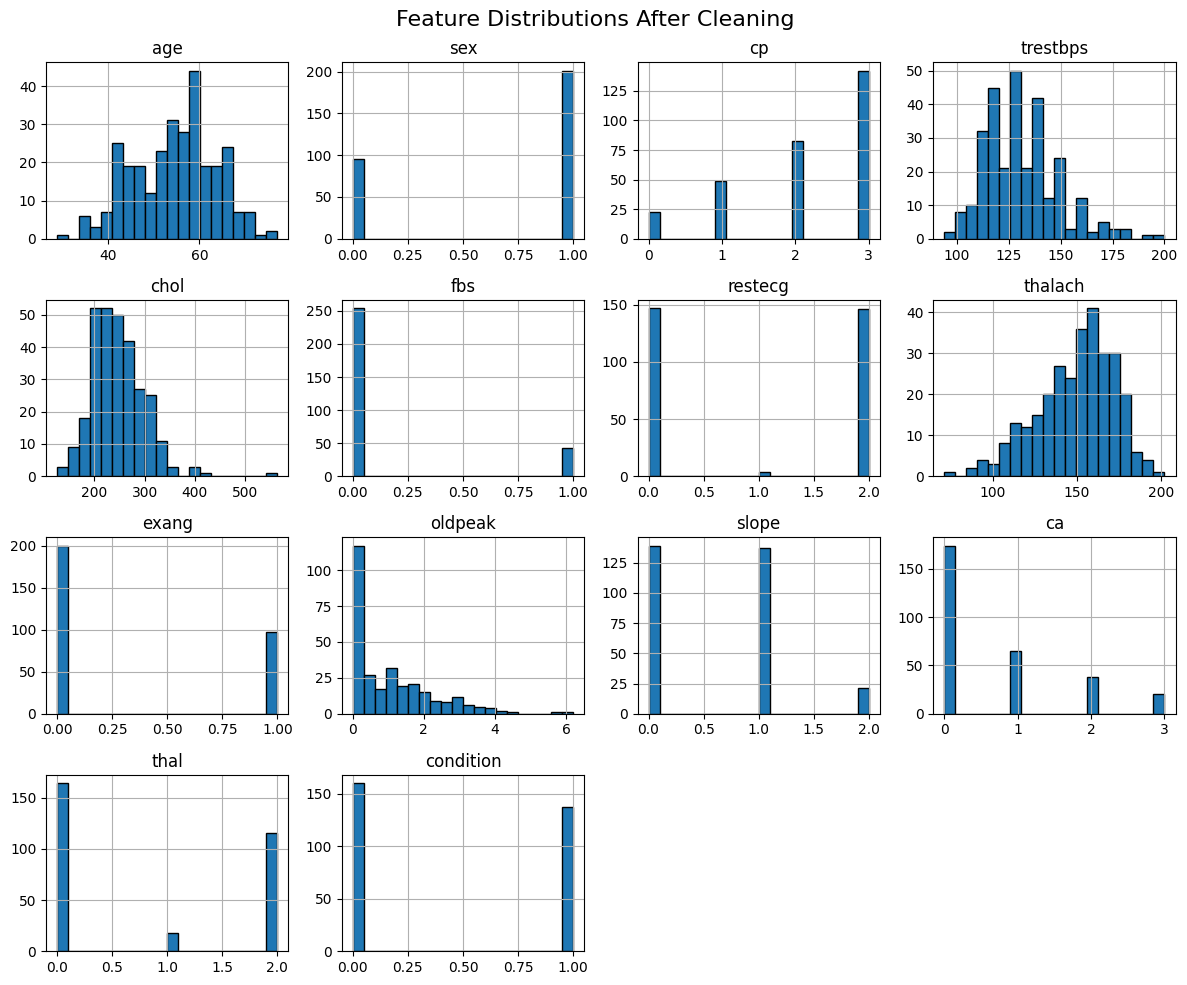

In [13]:
import matplotlib.pyplot as plt

# Plot all numeric feature distributions
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle("Feature Distributions After Cleaning", fontsize=16)
plt.tight_layout()
plt.show()


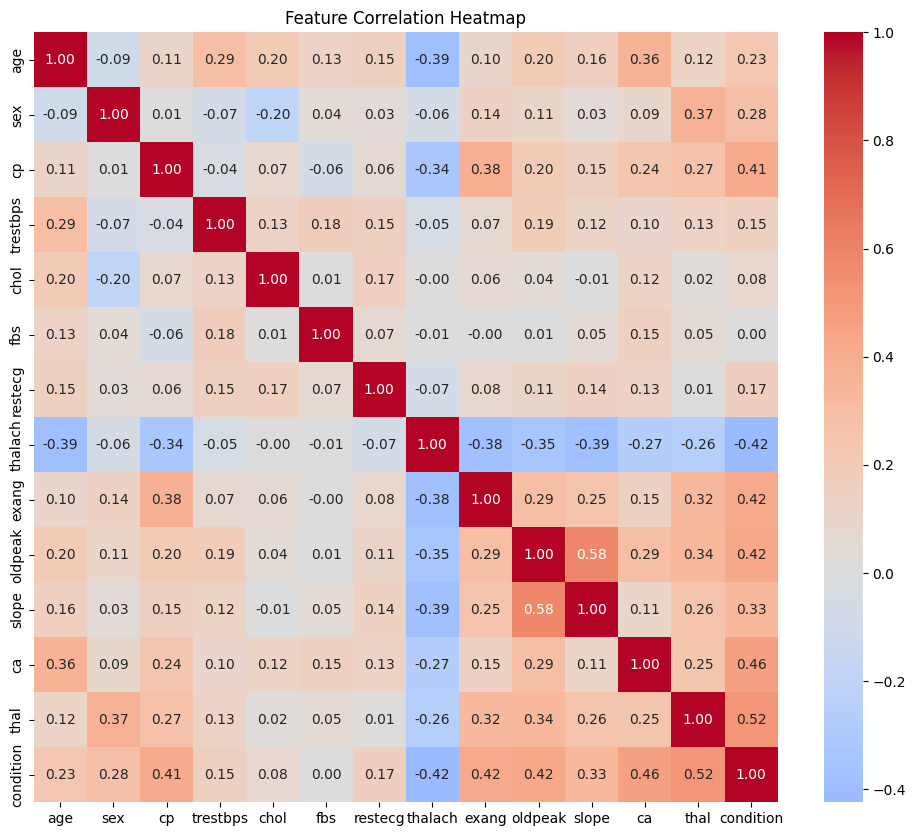

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()


### Step 7: Move Target Column to Front

SageMaker's XGBoost expects the label column (here, 'Outcome') to be the **first column** in the dataset.

We will move the 'Outcome' column from its current position to the front.


In [18]:
cols = df.columns.tolist()

# Remove 'Outcome' and insert at position 0
cols.insert(0, cols.pop(cols.index('condition')))
df = df[cols]
df.head()


,condition,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0,69,1,0,160,234,1,2,131,0,0.1,1,1,0
1,0,69,0,0,140,239,0,0,151,0,1.8,0,2,0
2,0,66,0,0,150,226,0,0,114,0,2.6,2,0,0
3,1,65,1,0,138,282,1,2,174,0,1.4,1,1,0
4,0,64,1,0,110,211,0,2,144,1,1.8,1,0,0


### Step 8: Split Dataset into Training and Validation Sets
- **Training set** (e.g., 80%)
- **Validation set** (e.g., 20%)

In [21]:
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['condition'])


# Save both files without header and index
train_df.to_csv('../dataset/clean/heart/train.csv', index=False, header=False)
val_df.to_csv('../dataset/clean/heart/validation.csv', index=False, header=False)


### Step 9: Upload Training and Validation Files to S3

In [22]:
import boto3

# S3 setup
bucket_name = 'evangadi-ai'
train_key = 'train/heart_train.csv'
val_key = 'test/heart_test.csv'

s3 = boto3.resource('s3')

s3.Bucket(bucket_name).upload_file('../dataset/clean/heart/train.csv', train_key)
s3.Bucket(bucket_name).upload_file('../dataset/clean/heart/validation.csv', val_key)

print("✅ Files uploaded successfully.")

✅ Files uploaded successfully.


### we have finished the data prepairing and trating step next we will train the model using xg-boost model

 ## ✅ Phase 2: Local Training Job Execution




In [28]:
# train_model_cloud.py

import sagemaker
from sagemaker.inputs import TrainingInput
from sagemaker.estimator import Estimator
import boto3
import os

# 1. Create SageMaker session and IAM role
session = sagemaker.Session()
role = "arn:aws:iam::200110254389:role/service-role/AmazonSageMaker-ExecutionRole-20250702T122723"

# 2. Define S3 input paths
bucket = 'evangadi-ai'

train_input = TrainingInput(f's3://{bucket}/train/heart_train.csv', content_type='text/csv')
val_input = TrainingInput(f's3://{bucket}/test/heart_test.csv', content_type='text/csv')

# 3. Get XGBoost container image URI
container = sagemaker.image_uris.retrieve("xgboost", region="us-east-1", version="1.5-1")

# 4. Create XGBoost Estimator (Cloud Mode)
xgb_estimator = Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type='ml.m5.large',  # You can change to 'ml.t2.medium' for Free Tier
    output_path=f's3://{bucket}/output',
    sagemaker_session=session,
 base_job_name="heart-disease-xgb"
)

# 5. Set hyperparameters
xgb_estimator.set_hyperparameters(
    objective="binary:logistic",
    num_round=100,
    max_depth=5,
    eta=0.2,
    gamma=4,
    min_child_weight=6,
    subsample=0.8,
    verbosity=1
)

# 6. Launch training job in the cloud
xgb_estimator.fit({'train': train_input, 'validation': val_input})


INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: heart-disease-xgb-2025-07-13-13-00-27-798


2025-07-13 13:00:50 Starting - Starting the training job...
2025-07-13 13:01:23 Downloading - Downloading input data......
2025-07-13 13:02:03 Downloading - Downloading the training image...
2025-07-13 13:02:59 Training - Training image download completed. Training in progress../miniconda3/lib/python3.8/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index
[2025-07-13 13:03:04.942 ip-10-2-212-69.ec2.internal:8 INFO utils.py:28] RULE_JOB_STOP_SIGNAL_FILENAME: None
[2025-07-13 13:03:04.963 ip-10-2-212-69.ec2.internal:8 INFO profiler_config_parser.py:111] User has disabled profiler.
[2025-07-13:13:03:05:INFO] Imported framework sagemaker_xgboost_container.training
[2025-07-13:13:03:05:INFO] Failed to parse hyperparameter objective value binary:logistic to Json.
Returning the value itself
[2025-07-13:13:03:05:INFO

### Find your trained model path


In [29]:
model_path = xgb_estimator.model_data
print(model_path)

s3://evangadi-ai/output/heart-disease-xgb-2025-07-13-13-00-27-798/output/model.tar.gz


Download the model locally

In [30]:
import boto3
import tarfile
import os

# 1. Download the model tar.gz file
s3 = boto3.client('s3')
bucket_name = 'evangadi-ai'  
key = 'output/heart-disease-xgb-2025-07-13-13-00-27-798/output/model.tar.gz'  

local_model_path = '../model/model.tar.gz'
s3.download_file(bucket_name, key, local_model_path)

# 2. Extract the model.tar.gz
with tarfile.open(local_model_path) as tar:
    tar.extractall(path='model')


## we downlode the trained model after this step we will test it


In [31]:
import xgboost as xgb

model = xgb.Booster()
model.load_model("../model/heart-xgboost-model")


In [34]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score
import numpy as np



# Load the validation CSV without headers
df = pd.read_csv("./../dataset/clean/heart/validation.csv", header=None)

# First column is label
y_test = df.iloc[:, 0]
X_test = df.iloc[:, 1:]

# Convert DataFrame to DMatrix
dtest = xgb.DMatrix(X_test)

# Make predictions
y_pred_proba = model.predict(dtest)
y_pred = np.round(y_pred_proba)  # Round probabilities to get binary prediction

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)

print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision * 100, 2), "%")

# Optional: Show label distribution
print("Label distribution in predictions:", pd.Series(y_pred).value_counts())
print("Label distribution in actual data:", y_test.value_counts())


Accuracy: 83.33 %
Precision: 90.91 %
Label distribution in predictions: 0.0    38
1.0    22
Name: count, dtype: int64
Label distribution in actual data: 0
0    32
1    28
Name: count, dtype: int64


## testing with a random number

In [39]:
import pandas as pd
import xgboost as xgb

# Example test input (replace with real patient data)
input_data = pd.DataFrame([{
    "age": 51,
    "sex": 1,
    "cp": 3,
    "trestbps": 140,
    "chol": 298,
    "fbs": 0,
    "restecg": 0,
    "thalach": 122,
    "exang": 1,
    "oldpeak": 4.2,
    "slope": 1,
    "ca": 3,
    "thal": 2
}])

# Convert to DMatrix (used by XGBoost)
dmatrix = xgb.DMatrix(input_data)



# Predict
prediction = model.predict(dmatrix)

# Interpret result
label = int(prediction[0] >= 0.5)
print("Predicted Label:", label)        # 1 = Heart disease likely, 0 = Not likely
print("Probability:", float(prediction[0]))


Predicted Label: 1
Probability: 0.9669452905654907
